# Uncertainty Breakdown Analysis for Differential Cross Sections

This notebook performs a **systematic uncertainty breakdown analysis** comparing JEFF-4.0 with a user-generated ENDF evaluation.

## Analysis Structure
1. **Baseline**: Differential cross section from ACE data (no uncertainties)
2. **Cross Section (XS) Only**: Uncertainty from total cross section (δσ/σ)
3. **Individual Legendre Orders**: Uncertainty from each order L=1, 2, 3, ... separately
4. **Cumulative Legendre**: Progressive addition of L=1, then L=1+2, then L=1+2+3, etc.
5. **Combined (XS + All Legendre)**: Total uncertainty from all sources

## Data Sources
- **Angular distributions**: ACE files (cross sections) + ENDF MF4 (Legendre coefficients)
- **Cross section uncertainties**: Groupwise covariance GENDF files
- **Legendre coefficient uncertainties**: MF34 from ENDF files
- **Experimental data**: EXFOR database via kika

## Key Features
- Uses **kika** package functions for all data loading and processing
- Correct FWHM → σ conversion for TOF energy resolution
- BIN LOOKUP for MF34 uncertainties (not interpolation)
- Comparison between JEFF-4.0 and user's generated ENDF evaluation
- EXFOR data overlay with LAB→CM transformation

## 1. Configuration

All user-configurable parameters are defined here. Modify these values as needed.

In [19]:
# =============================================================================
# USER CONFIGURABLE PARAMETERS
# =============================================================================

# Analysis energy (MeV) - change this to investigate different energies
ANALYSIS_ENERGY_MEV = 1.31

# Uncertainty confidence level
N_SIGMA = 1.0  # Number of standard deviations for uncertainty bands

# Maximum Legendre order for analysis
MAX_LEGENDRE_ORDER = 6

# TOF folding parameters
APPLY_FOLDING = True
DELTA_T_NS = 10.0             # Time resolution FWHM (ns) - NOT sigma!
FLIGHT_PATH_M = 27.037        # Flight path length (m) - GELINA

# Plot settings
PLOT_YSCALE = 'log'  # 'linear' or 'log'

# =============================================================================
# FILE PATHS - JEFF-4.0 (Reference Library)
# =============================================================================
ACE_FILE_JEFF = '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_40.02c'
ENDF_FILE_JEFF = '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt'
COV_FILE_JEFF = '/soft_snc/lib/cov/80/600/260560_80.06.xs.gendf'

# =============================================================================
# FILE PATHS - User's Generated ENDF (to compare with JEFF)
# =============================================================================
# NOTE: The user's generated ENDF is compared using the SAME ACE and COV files
# This isolates the effect of the angular distribution (MF4) differences

ENDF_FILE_USER = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g_evaluation_V4_ENERGYBIN.endf"

# Nuclear masses (atomic mass units)
M_NEUTRON = 1.008665    # neutron mass
M_FE56 = 55.93494       # Fe-56 mass

# Isotope and reaction identifiers
ZAID = 26056  # Fe-56
MT_ELASTIC = 2  # Elastic scattering

# =============================================================================
# EXFOR Data Configuration
# =============================================================================
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
ENERGY_TOLERANCE = 0.015  # MeV tolerance for EXFOR energy matching

# Supplementary JSON files (experiments not in database)
SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',  # Gkatis (2025)
]

# Experiment exclusion and uncertainty handling
# Use this to exclude specific experiments from the analysis
EXCLUDE_EXPERIMENTS = ["20743002"]  # e.g., ["20743002"] to exclude Cierjacks (1978)

# Minimum relative uncertainty floor (set to 0.0 to disable)
# This prevents experiments with unrealistically small uncertainties from dominating
MIN_RELATIVE_UNCERTAINTY = 0.0  # e.g., 0.03 for 3% minimum uncertainty floor

print(f"Configuration loaded.")
print(f"Analysis energy: {ANALYSIS_ENERGY_MEV} MeV")
print(f"Folding: {'Enabled' if APPLY_FOLDING else 'Disabled'}")
if APPLY_FOLDING:
    print(f"  - delta_t (FWHM): {DELTA_T_NS} ns")
    print(f"  - flight path: {FLIGHT_PATH_M} m")
print(f"Supplementary JSON files: {len(SUPPLEMENTARY_JSON_FILES)}")
print(f"Excluded experiments: {EXCLUDE_EXPERIMENTS if EXCLUDE_EXPERIMENTS else 'None'}")
if MIN_RELATIVE_UNCERTAINTY > 0:
    print(f"Min relative uncertainty floor: {MIN_RELATIVE_UNCERTAINTY*100:.1f}%")

Configuration loaded.
Analysis energy: 1.31 MeV
Folding: Enabled
  - delta_t (FWHM): 10.0 ns
  - flight path: 27.037 m
Supplementary JSON files: 1
Excluded experiments: ['20743002']


## 2. Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import legendre

# Add kika to path if needed
_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

# Import kika modules
import kika
from kika.endf import read_endf
from kika.cov.parse_covmat import read_njoy_covmat
from kika.exfor import read_all_exfor
import kika.exfor as exfor

# Import energy folding utilities (now with correct FWHM -> sigma conversion)
from kika.utils.energy_folding import (
    EnergyFoldingConfig,
    FWHM_TO_SIGMA,
    compute_energy_resolution_tof,
    fold_cross_section,
    endf_angular_distribution,
    compute_folded_differential_xs,
    compute_unfolded_differential_xs,
)

# Import EXFOR utilities for proper data extraction
from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    filter_exfor_with_energy_bin,
)

# Configure matplotlib
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 8)

print("Imports successful!")
print(f"FWHM_TO_SIGMA constant: {FWHM_TO_SIGMA:.5f}")

Imports successful!
FWHM_TO_SIGMA constant: 2.35482


## 3. Helper Functions

These functions are adapted from `uncertainty_analysis_utils.py` to work with kika data structures.

In [3]:
# =============================================================================
# UNCERTAINTY EXTRACTION FUNCTIONS
# =============================================================================

def get_cross_section_uncertainty(cov_mat, zaid, mt, energy_mev):
    """
    Get relative uncertainty (δσ/σ) from covariance matrix.
    
    Parameters
    ----------
    cov_mat : CovMat
        Covariance matrix object from kika.cov.parse_covmat
    zaid : int
        ZAID identifier (e.g., 26056 for Fe-56)
    mt : int
        Reaction MT number (e.g., 2 for elastic scattering)
    energy_mev : float
        Energy in MeV
    
    Returns
    -------
    float
        Relative uncertainty as fraction (not percentage)
    """
    try:
        return cov_mat.get_uncertainty(zaid, mt, energy_mev)
    except Exception as e:
        print(f"Warning: Could not get XS uncertainty: {e}")
        return 0.0


def get_legendre_coefficient_uncertainty(mf34_covmat, endf_data, zaid, mt, energy_mev, order):
    """
    Get ABSOLUTE uncertainty for a single Legendre coefficient at a specific energy.
    
    CRITICAL: Properly uses MF34 binned data structure with bin boundary handling.
    - Uncertainty is constant within each energy bin
    - For relative->absolute conversion: extracts A_l at target energy from MF4
    - BIN BOUNDARY HANDLING: If energy is exactly at a bin boundary,
      uses the bin STARTING at that energy
    
    Parameters
    ----------
    mf34_covmat : MF34CovMat or None
        MF34 covariance matrix object
    endf_data : ENDF object
        ENDF data containing MF=4 for Legendre coefficients
    zaid : int
        ZAID identifier
    mt : int
        Reaction MT number
    energy_mev : float
        Target energy in MeV
    order : int
        Legendre order (1, 2, 3, ...)
    
    Returns
    -------
    dict
        Dictionary containing:
            - 'absolute': Absolute uncertainty σ_al
            - 'relative': Relative uncertainty (δA_l/A_l) as fraction
            - 'is_relative': Whether MF34 data was originally relative
    """
    if mf34_covmat is None:
        return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
    
    try:
        # Get uncertainty data from MF34 (binned, may be relative or absolute)
        unc_data = mf34_covmat.get_uncertainties_for_legendre_coefficient(zaid, mt, order)
        
        if unc_data is None:
            return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
        
        energies = unc_data['energies']  # Bin boundaries in eV
        unc_values = unc_data['uncertainties']  # Uncertainty per bin
        is_relative = unc_data['is_relative']
        
        # Convert input energy from MeV to eV
        energy_ev = energy_mev * 1e6
        
        # Find which bin contains the target energy
        bin_idx = -1
        for i in range(len(energies) - 1):
            if energies[i] <= energy_ev < energies[i+1]:
                bin_idx = i
                break
        else:
            # Special case: if exactly at last boundary, use last bin
            if abs(energy_ev - energies[-1]) < 1e-6:
                bin_idx = len(unc_values) - 1
        
        if bin_idx < 0:
            return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
        
        # Get the uncertainty for this bin
        unc_at_energy = unc_values[bin_idx]
        
        # If already absolute, return it
        if not is_relative:
            return {
                'absolute': unc_at_energy,
                'relative': 0.0,
                'is_relative': False
            }
        
        # Convert relative to absolute: σ_abs = σ_rel × |A_l|
        try:
            mf4_mt = endf_data.mf[4].mt[mt]
            coeffs_dict = mf4_mt.extract_legendre_coefficients(
                energy_ev, 
                max_legendre_order=order,
                out_of_range="zero"
            )
            
            if coeffs_dict is not None and order in coeffs_dict:
                A_ell = coeffs_dict[order]
                unc_absolute = unc_at_energy * abs(A_ell)
                return {
                    'absolute': unc_absolute,
                    'relative': unc_at_energy,
                    'is_relative': True
                }
            else:
                return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
        except Exception:
            return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
        
    except Exception as e:
        print(f"Warning: Could not get uncertainty for L={order}: {e}")
        return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}


print("Helper functions defined.")

Helper functions defined.


In [4]:
# =============================================================================
# FOLDING AND CROSS SECTION FUNCTIONS
# =============================================================================

def get_folded_cross_section(ace_data, target_energy_mev, mt, delta_t_ns, flight_path_m, n_sigma=4.0):
    """
    Get Gaussian-folded cross section using kika's energy_folding module.
    
    Parameters
    ----------
    ace_data : ACEData
        ACE data object from kika.read_ace()
    target_energy_mev : float
        Target energy in MeV
    mt : int
        Reaction MT number
    delta_t_ns : float
        Time resolution FWHM in nanoseconds
    flight_path_m : float
        Flight path in meters
    n_sigma : float
        Number of sigma for integration window
    
    Returns
    -------
    tuple
        (folded_xs, unfolded_xs, sigma_E_mev)
    """
    # Compute sigma_E using corrected FWHM -> sigma conversion
    config = EnergyFoldingConfig(
        flight_path_m=flight_path_m,
        delta_t_ns=delta_t_ns,
        n_sigma=n_sigma,
    )
    sigma_E_mev = compute_energy_resolution_tof(target_energy_mev, config)
    
    # Get folded cross section
    folded_xs, unfolded_xs = fold_cross_section(
        ace_data=ace_data,
        target_energy_mev=target_energy_mev,
        mt=mt,
        sigma_E_mev=sigma_E_mev,
        n_sigma=n_sigma,
    )
    
    return folded_xs, unfolded_xs, sigma_E_mev


def calculate_differential_xs_with_uncertainty(
    ace_data, endf_data, cov_mat, mf34_covmat, 
    energy_mev, mt, zaid,
    include_xs_unc=False, legendre_orders=None,
    n_sigma=1.0, apply_folding=False, delta_t_ns=10.0, flight_path_m=27.037,
    n_angular_points=100
):
    """
    Calculate differential cross section with specified uncertainty sources.
    
    Parameters
    ----------
    ace_data : ACEData
        ACE data for cross sections
    endf_data : ENDF
        ENDF data for Legendre coefficients
    cov_mat : CovMat
        Covariance matrix for XS uncertainties
    mf34_covmat : MF34CovMat
        MF34 covariance for Legendre uncertainties
    energy_mev : float
        Energy in MeV
    mt : int
        Reaction MT number
    zaid : int
        ZAID identifier
    include_xs_unc : bool
        Include cross section uncertainty
    legendre_orders : list or None
        List of Legendre orders to include uncertainties for
    n_sigma : float
        Confidence level in sigma
    apply_folding : bool
        Apply energy folding
    delta_t_ns : float
        Time resolution FWHM (ns)
    flight_path_m : float
        Flight path (m)
    n_angular_points : int
        Number of angular grid points
    
    Returns
    -------
    dict
        Results dictionary with 'mu', 'dsigma', 'dsigma_plus', 'dsigma_minus', 'sigma_total'
    """
    # Get cross section (folded or unfolded)
    if apply_folding:
        sigma_total, sigma_unfolded, sigma_E = get_folded_cross_section(
            ace_data, energy_mev, mt, delta_t_ns, flight_path_m
        )
    else:
        xs_df = ace_data.get_cross_section(mt)
        energies = xs_df['Energy'].values
        xs_values = xs_df[f'MT={mt}'].values
        sigma_total = np.interp(energy_mev, energies, xs_values)
    
    # Get Legendre coefficients from ENDF MF4
    energy_ev = energy_mev * 1e6
    mf4_mt = endf_data.mf[4].mt[mt]
    coeffs_dict = mf4_mt.extract_legendre_coefficients(
        energy_ev, 
        max_legendre_order=10,
        out_of_range="zero"
    )
    
    # Build coefficient array [a1, a2, ...] (a0=1 is implicit)
    max_order = max(coeffs_dict.keys()) if coeffs_dict else 0
    endf_coeffs = np.array([coeffs_dict.get(i, 0.0) for i in range(1, max_order + 1)])
    
    # Create angular grid
    mu = np.linspace(-1, 1, n_angular_points)
    
    # Compute angular distribution f(mu)
    f_mu = endf_angular_distribution(mu, endf_coeffs)
    
    # Baseline differential cross section: dσ/dΩ = σ × f(μ) / (2π)
    dsigma = sigma_total * f_mu / (2 * np.pi)
    
    # Compute uncertainties
    delta_dsigma_squared = np.zeros_like(mu)
    
    # XS uncertainty contribution
    if include_xs_unc:
        delta_sigma_rel = get_cross_section_uncertainty(cov_mat, zaid, mt, energy_mev)
        delta_sigma = delta_sigma_rel * sigma_total
        # d(dσ/dΩ)/dσ = f(μ)/(2π)
        delta_dsigma_squared += (f_mu / (2 * np.pi) * delta_sigma) ** 2
    
    # Legendre coefficient uncertainty contributions
    if legendre_orders is not None:
        for order in legendre_orders:
            unc_info = get_legendre_coefficient_uncertainty(
                mf34_covmat, endf_data, zaid, mt, energy_mev, order
            )
            delta_a = unc_info['absolute']
            if delta_a > 0:
                # Derivative of f(μ) with respect to a_l: (2l+1)/2 × P_l(μ)
                P_l = legendre(order)(mu)
                df_da = (2 * order + 1) / 2 * P_l
                # d(dσ/dΩ)/da_l = σ/(2π) × df/da_l
                delta_dsigma_squared += (sigma_total / (2 * np.pi) * df_da * delta_a) ** 2
    
    # Total uncertainty
    delta_dsigma = np.sqrt(delta_dsigma_squared)
    
    return {
        'mu': mu,
        'dsigma': dsigma,
        'dsigma_plus': dsigma + n_sigma * delta_dsigma,
        'dsigma_minus': dsigma - n_sigma * delta_dsigma,
        'delta_dsigma': delta_dsigma,
        'sigma_total': sigma_total,
    }


print("Differential XS functions defined.")

Differential XS functions defined.


In [5]:
# =============================================================================
# SYSTEMATIC ANALYSIS FUNCTION
# =============================================================================

def perform_systematic_analysis(
    ace_data, cov_mat, mf34_covmat, endf_data, zaid, mt, energy_mev,
    max_legendre_order, library_name, n_sigma=1.0,
    apply_folding=False, delta_t_ns=10.0, flight_path_m=27.037
):
    """
    Perform systematic uncertainty breakdown analysis.
    
    Computes differential cross sections with various uncertainty contributions:
    1. Baseline (no uncertainties)
    2. Cross section uncertainty only
    3. Individual Legendre orders (L=1, L=2, L=3, ...)
    4. Cumulative Legendre (L=1, L=1+2, L=1+2+3, ...)
    5. Combined (cross section + all Legendre orders)
    
    Returns
    -------
    dict
        Nested dictionary with results for each analysis type
    """
    results = {}
    
    print(f"\nAnalyzing {library_name} at E = {energy_mev} MeV")
    if apply_folding:
        print(f"  Folding enabled (delta_t={delta_t_ns} ns FWHM, L={flight_path_m} m)")
    print("=" * 80)
    
    common_args = dict(
        ace_data=ace_data,
        endf_data=endf_data,
        cov_mat=cov_mat,
        mf34_covmat=mf34_covmat,
        energy_mev=energy_mev,
        mt=mt,
        zaid=zaid,
        n_sigma=n_sigma,
        apply_folding=apply_folding,
        delta_t_ns=delta_t_ns,
        flight_path_m=flight_path_m,
    )
    
    # 1. Baseline (no uncertainties)
    print("1. Baseline (no uncertainties)...")
    results['baseline'] = calculate_differential_xs_with_uncertainty(
        **common_args, include_xs_unc=False, legendre_orders=None
    )
    
    # 2. Cross section only
    print("2. Cross section uncertainty only...")
    results['xs_only'] = calculate_differential_xs_with_uncertainty(
        **common_args, include_xs_unc=True, legendre_orders=None
    )
    
    # 3. Individual Legendre orders
    results['individual_legendre'] = {}
    for order in range(1, max_legendre_order + 1):
        print(f"3.{order}. Legendre L={order} only...")
        results['individual_legendre'][order] = calculate_differential_xs_with_uncertainty(
            **common_args, include_xs_unc=False, legendre_orders=[order]
        )
    
    # 4. Cumulative Legendre
    results['cumulative_legendre'] = {}
    for max_order in range(1, max_legendre_order + 1):
        orders = list(range(1, max_order + 1))
        print(f"4.{max_order}. Legendre L=1 to {max_order}...")
        results['cumulative_legendre'][max_order] = calculate_differential_xs_with_uncertainty(
            **common_args, include_xs_unc=False, legendre_orders=orders
        )
    
    # 5. Combined (XS + all Legendre)
    print(f"5. Combined (XS + all Legendre L=1 to {max_legendre_order})...")
    all_orders = list(range(1, max_legendre_order + 1))
    results['combined'] = calculate_differential_xs_with_uncertainty(
        **common_args, include_xs_unc=True, legendre_orders=all_orders
    )
    
    print("\u2713 Analysis complete")
    print("=" * 80)
    
    return results


print("Systematic analysis function defined.")

Systematic analysis function defined.


## 4. Load Data

In [6]:
# Load ACE file (shared for both evaluations)
print("Loading ACE file...")
ace_data = kika.read_ace(ACE_FILE_JEFF)
print(f"\u2713 ACE file loaded")

# Load ENDF files
print("\nLoading ENDF files...")
endf_jeff = read_endf(ENDF_FILE_JEFF)
print(f"\u2713 JEFF-4.0 ENDF loaded")

try:
    endf_user = read_endf(ENDF_FILE_USER)
    print(f"\u2713 User ENDF loaded")
    user_endf_available = True
except Exception as e:
    print(f"\u26a0 Could not load User ENDF: {e}")
    print(f"  Please update ENDF_FILE_USER path in the configuration section.")
    endf_user = None
    user_endf_available = False

# Load covariance file (shared)
print("\nLoading covariance file...")
cov_matrix = read_njoy_covmat(COV_FILE_JEFF)
print(f"\u2713 Covariance file loaded: {len(cov_matrix.energy_grid)} energy groups")

# Extract MF34 covariance data
print("\nExtracting MF34 angular covariance data...")
try:
    mf34_jeff = endf_jeff.mf[34].mt[MT_ELASTIC].to_ang_covmat()
    available_orders_jeff = sorted(mf34_jeff.legendre_indices)
    print(f"\u2713 JEFF-4.0 MF34: {mf34_jeff.num_matrices} matrices, orders: {available_orders_jeff}")
except Exception as e:
    print(f"\u26a0 Could not load JEFF-4.0 MF34 data: {e}")
    mf34_jeff = None
    available_orders_jeff = []

mf34_user = None
available_orders_user = []
if user_endf_available:
    try:
        mf34_user = endf_user.mf[34].mt[MT_ELASTIC].to_ang_covmat()
        available_orders_user = sorted(mf34_user.legendre_indices)
        print(f"\u2713 User MF34: {mf34_user.num_matrices} matrices, orders: {available_orders_user}")
    except Exception as e:
        print(f"\u26a0 Could not load User MF34 data: {e}")
        print(f"  (This is expected if your ENDF doesn't have MF34 covariance data)")

print("\n" + "=" * 80)
print("DATA LOADING COMPLETE")
print("=" * 80)

Loading ACE file...
✓ ACE file loaded

Loading ENDF files...


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:90: UserWarning: Skipping MF sections without parsers: [2, 3, 6, 8, 10, 12, 14, 33]. Only parsing: [1, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


✓ JEFF-4.0 ENDF loaded
✓ User ENDF loaded

Loading covariance file...
✓ Covariance file loaded: 57 energy groups

Extracting MF34 angular covariance data...
✓ JEFF-4.0 MF34: 21 matrices, orders: [1, 2, 3, 4, 5, 6]
✓ User MF34: 36 matrices, orders: [1, 2, 3, 4, 5, 6, 7, 8]

DATA LOADING COMPLETE


## 5. Load EXFOR Data

In [30]:
# Configure EXFOR database
exfor.configure(db_path=EXFOR_DB_PATH)

# Load EXFOR angular distribution data
print("Loading EXFOR data from database...")
try:
    exfor_dict = read_all_exfor(
        target=[ZAID, 26000],  # Fe-56 + natural Fe
        mt=MT_ELASTIC,
        source="database",
        group_by_energy=False,  # Important: don't group by energy for cache format
        supplementary_json_files=SUPPLEMENTARY_JSON_FILES,  # Include supplementary experiments
        exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
    )
    
    # Convert to cache format for proper filtering
    exfor_objects = list(exfor_dict.values())
    exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
        exfor_objects,
        exclude_experiments=EXCLUDE_EXPERIMENTS,  # Double-check exclusion
    )
    
    print(f"Loaded {len(exfor_objects)} EXFOR datasets")
    print(f"  Unique energies: {len(sorted_exfor_energies)}")
    print(f"  Energy range: [{min(sorted_exfor_energies):.4f}, {max(sorted_exfor_energies):.4f}] MeV")
    if EXCLUDE_EXPERIMENTS:
        print(f"  Excluded experiments: {EXCLUDE_EXPERIMENTS}")
    if SUPPLEMENTARY_JSON_FILES:
        print(f"  Supplementary files loaded: {len(SUPPLEMENTARY_JSON_FILES)}")
    exfor_available = True
    
except Exception as e:
    print(f"Could not load EXFOR data: {e}")
    exfor_cache = None
    sorted_exfor_energies = None
    exfor_available = False

Loading EXFOR data from database...
Loaded 119 EXFOR datasets
  Unique energies: 8796
  Energy range: [0.0350, 96.0000] MeV
  Excluded experiments: ['20743002']
  Supplementary files loaded: 1


In [31]:
# Filter EXFOR data for the analysis energy using energy bin method
if exfor_available and exfor_cache is not None:
    print(f"Filtering EXFOR data for E = {ANALYSIS_ENERGY_MEV} MeV +/- {ENERGY_TOLERANCE*1000:.1f} keV...")
    
    # Compute bin boundaries
    bin_lower_mev = ANALYSIS_ENERGY_MEV - ENERGY_TOLERANCE
    bin_upper_mev = ANALYSIS_ENERGY_MEV + ENERGY_TOLERANCE
    
    # Use the filter_exfor_with_energy_bin function (same as single_energy_fitting_demo)
    exfor_df, experiments_info, kernel_weights, diagnostics = filter_exfor_with_energy_bin(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        bin_lower_mev=bin_lower_mev,
        bin_upper_mev=bin_upper_mev,
        target_energy_mev=ANALYSIS_ENERGY_MEV,
        m_proj_u=M_NEUTRON,
        m_targ_u=M_FE56,
        dedupe_per_experiment=True,  # Select closest energy per experiment
        exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,  # Apply uncertainty floor
    )
    
    # Add experiment_id column for plotting
    if not exfor_df.empty and 'experiment_id' not in exfor_df.columns:
        exfor_df['experiment_id'] = exfor_df['entry'] + '/' + exfor_df['subentry']
    
    if not exfor_df.empty:
        n_experiments = len(experiments_info)
        n_points = len(exfor_df)
        print(f"Found {n_points} EXFOR data points from {n_experiments} experiments")
        print(f"  within [{bin_lower_mev:.4f}, {bin_upper_mev:.4f}] MeV")
        
        # Show experiments found
        print(f"\nExperiments:")
        for exp in experiments_info:
            author = exp.get('author', 'Unknown')
            year = exp.get('year', '????')
            n_pts = exp.get('n_points', 0)
            e_exfor = exp.get('exfor_energy_mev', 0)
            entry = exp.get('entry', '')
            subentry = exp.get('subentry', '')
            print(f"  {entry}/{subentry}: {author} ({year}) - {n_pts} points @ {e_exfor:.4f} MeV")
        
        if diagnostics:
            print(f"\nDiagnostics:")
            print(f"  N_eff (effective sample size): {diagnostics.n_eff:.1f}")
            if diagnostics.experiment_weights:
                print(f"  Experiment weight fractions:")
                for exp_key, frac in sorted(diagnostics.experiment_weights.items(), key=lambda x: -x[1]):
                    print(f"    {exp_key}: {frac*100:.1f}%")
    else:
        print(f"No EXFOR data found within tolerance of E = {ANALYSIS_ENERGY_MEV} MeV")
        exfor_df = None
else:
    exfor_df = None
    experiments_info = []
    print("EXFOR data not available")

Filtering EXFOR data for E = 1.31 MeV +/- 15.0 keV...
Found 34 EXFOR data points from 4 experiments
  within [1.2950, 1.3250] MeV

Experiments:
  10571/002: Kinney (1976) - 8 points @ 1.3100 MeV
  20197/006: Malmskog (1972) - 7 points @ 1.3000 MeV
  14462/002: Ramirez (2017) - 11 points @ 1.3000 MeV
  27673/27673002: G. Gkatis (2025) - 8 points @ 1.3099 MeV

Diagnostics:
  N_eff (effective sample size): 34.0
  Experiment weight fractions:
    14462.002: 32.4%
    10571.002: 23.5%
    27673.27673002: 23.5%
    20197.006: 20.6%


## 6. Verify Energy Resolution Calculation

Verify that the FWHM → σ conversion is working correctly.

In [32]:
# Test energy resolution calculation
config = EnergyFoldingConfig(flight_path_m=FLIGHT_PATH_M, delta_t_ns=DELTA_T_NS)
sigma_E = compute_energy_resolution_tof(ANALYSIS_ENERGY_MEV, config)

print(f"Energy resolution at E = {ANALYSIS_ENERGY_MEV} MeV:")
print(f"  delta_t (FWHM): {DELTA_T_NS} ns")
print(f"  flight path: {FLIGHT_PATH_M} m")
print(f"  \u03c3E = {sigma_E * 1000:.2f} keV")
print(f"  FWHM_E = {sigma_E * FWHM_TO_SIGMA * 1000:.2f} keV")
print(f"")
print(f"Note: \u03c3E = FWHM_E / {FWHM_TO_SIGMA:.5f}")

Energy resolution at E = 1.31 MeV:
  delta_t (FWHM): 10.0 ns
  flight path: 27.037 m
  σE = 6.51 keV
  FWHM_E = 15.34 keV

Note: σE = FWHM_E / 2.35482


## 7. Run Analysis for JEFF-4.0 (Reference)

In [33]:
results_jeff = perform_systematic_analysis(
    ace_data, cov_matrix, mf34_jeff, endf_jeff, ZAID, MT_ELASTIC,
    ANALYSIS_ENERGY_MEV, MAX_LEGENDRE_ORDER, "JEFF-4.0", n_sigma=N_SIGMA,
    apply_folding=APPLY_FOLDING, delta_t_ns=DELTA_T_NS, flight_path_m=FLIGHT_PATH_M
)


Analyzing JEFF-4.0 at E = 1.31 MeV
  Folding enabled (delta_t=10.0 ns FWHM, L=27.037 m)
1. Baseline (no uncertainties)...
2. Cross section uncertainty only...
3.1. Legendre L=1 only...
3.2. Legendre L=2 only...
3.3. Legendre L=3 only...
3.4. Legendre L=4 only...
3.5. Legendre L=5 only...
3.6. Legendre L=6 only...
4.1. Legendre L=1 to 1...
4.2. Legendre L=1 to 2...
4.3. Legendre L=1 to 3...
4.4. Legendre L=1 to 4...
4.5. Legendre L=1 to 5...
4.6. Legendre L=1 to 6...
5. Combined (XS + all Legendre L=1 to 6)...
✓ Analysis complete


## 8. Run Analysis for User's ENDF (if available)

In [34]:
if user_endf_available:
    # Determine max Legendre order for user ENDF
    user_max_order = min(MAX_LEGENDRE_ORDER, max(available_orders_user) if available_orders_user else MAX_LEGENDRE_ORDER)
    
    results_user = perform_systematic_analysis(
        ace_data, cov_matrix, mf34_user, endf_user, ZAID, MT_ELASTIC,
        ANALYSIS_ENERGY_MEV, user_max_order, "User ENDF", n_sigma=N_SIGMA,
        apply_folding=APPLY_FOLDING, delta_t_ns=DELTA_T_NS, flight_path_m=FLIGHT_PATH_M
    )
else:
    results_user = None
    print("\u26a0 User ENDF not available. Skipping user analysis.")
    print("  Please update ENDF_FILE_USER in the configuration section.")


Analyzing User ENDF at E = 1.31 MeV
  Folding enabled (delta_t=10.0 ns FWHM, L=27.037 m)
1. Baseline (no uncertainties)...
2. Cross section uncertainty only...
3.1. Legendre L=1 only...
3.2. Legendre L=2 only...
3.3. Legendre L=3 only...
3.4. Legendre L=4 only...
3.5. Legendre L=5 only...
3.6. Legendre L=6 only...
4.1. Legendre L=1 to 1...
4.2. Legendre L=1 to 2...
4.3. Legendre L=1 to 3...
4.4. Legendre L=1 to 4...
4.5. Legendre L=1 to 5...
4.6. Legendre L=1 to 6...
5. Combined (XS + all Legendre L=1 to 6)...
✓ Analysis complete


## 9. Plotting Functions

In [35]:
# Color palette and markers for experiments (consistent style)
EXPERIMENT_COLORS = plt.cm.tab10.colors
EXPERIMENT_MARKERS = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']


def plot_exfor_data(ax, exfor_df, experiments_info, alpha=0.9, markersize=6):
    """
    Plot EXFOR data with different colors/markers per experiment.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot on
    exfor_df : pd.DataFrame
        EXFOR data with 'mu', 'value', 'unc', 'experiment_id' columns
    experiments_info : list
        List of experiment info dicts
    alpha : float
        Marker transparency
    markersize : float
        Marker size
    """
    if exfor_df is None or exfor_df.empty:
        return
    
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=EXPERIMENT_MARKERS[i % len(EXPERIMENT_MARKERS)],
            color=EXPERIMENT_COLORS[i % len(EXPERIMENT_COLORS)],
            label=label,
            capsize=3,
            markersize=markersize,
            alpha=alpha,
            markeredgewidth=0.5
        )


def plot_comparison(results_jeff, results_user, exfor_df, experiments_info, energy_mev, n_sigma, yscale='log'):
    """
    Plot comparison between JEFF-4.0 and User ENDF with EXFOR data overlay.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Colors for evaluations
    jeff_color = 'blue'
    user_color = 'red'
    
    # Left plot: Baseline comparison
    ax1 = axes[0]
    
    # JEFF-4.0 baseline
    mu_jeff = results_jeff['baseline']['mu']
    dsigma_jeff = results_jeff['baseline']['dsigma']
    ax1.plot(mu_jeff, dsigma_jeff, '-', color=jeff_color, linewidth=2, label='JEFF-4.0')
    
    # User ENDF baseline (if available)
    if results_user is not None:
        mu_user = results_user['baseline']['mu']
        dsigma_user = results_user['baseline']['dsigma']
        ax1.plot(mu_user, dsigma_user, '-', color=user_color, linewidth=2, label='User ENDF')
    
    # EXFOR data - different color per experiment
    plot_exfor_data(ax1, exfor_df, experiments_info, markersize=5)
    
    ax1.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=12)
    ax1.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
    ax1.set_title(f'Baseline Comparison @ E = {energy_mev} MeV', fontsize=14)
    ax1.set_xlim(-1, 1)
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)
    if yscale == 'log':
        ax1.set_yscale('log')
    
    # Right plot: Combined uncertainty comparison
    ax2 = axes[1]
    
    # JEFF-4.0 combined
    dsigma_jeff_comb = results_jeff['combined']['dsigma']
    dsigma_jeff_plus = results_jeff['combined']['dsigma_plus']
    dsigma_jeff_minus = results_jeff['combined']['dsigma_minus']
    ax2.fill_between(mu_jeff, dsigma_jeff_minus, dsigma_jeff_plus, 
                     alpha=0.3, color=jeff_color, label=f'JEFF-4.0 +/-{n_sigma}s')
    ax2.plot(mu_jeff, dsigma_jeff_comb, '-', color=jeff_color, linewidth=2)
    
    # User ENDF combined (if available)
    if results_user is not None:
        dsigma_user_comb = results_user['combined']['dsigma']
        dsigma_user_plus = results_user['combined']['dsigma_plus']
        dsigma_user_minus = results_user['combined']['dsigma_minus']
        ax2.fill_between(mu_user, dsigma_user_minus, dsigma_user_plus,
                         alpha=0.3, color=user_color, label=f'User ENDF +/-{n_sigma}s')
        ax2.plot(mu_user, dsigma_user_comb, '-', color=user_color, linewidth=2)
    
    # EXFOR data - different color per experiment
    plot_exfor_data(ax2, exfor_df, experiments_info, markersize=5)
    
    ax2.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=12)
    ax2.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
    ax2.set_title(f'Combined Uncertainty @ E = {energy_mev} MeV', fontsize=14)
    ax2.set_xlim(-1, 1)
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3)
    if yscale == 'log':
        ax2.set_yscale('log')
    
    plt.tight_layout()
    return fig


def plot_individual_legendre_grid(results, library_name, energy_mev, n_sigma, max_order,
                                   exfor_df=None, experiments_info=None, yscale='log'):
    """
    Plot individual Legendre contributions in a grid - one subplot per order.
    Each subplot shows: baseline + uncertainty band for L=order only.
    """
    n_cols = 3
    n_rows = (max_order + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if max_order > 1 else [axes]

    mu = results['baseline']['mu']
    dsigma_base = results['baseline']['dsigma']

    for order in range(1, max_order + 1):
        ax = axes[order - 1]
        ax.plot(mu, dsigma_base, 'k-', linewidth=1.5, label='Baseline')

        if order in results['individual_legendre']:
            res = results['individual_legendre'][order]
            ax.fill_between(mu, res['dsigma_minus'], res['dsigma_plus'],
                           alpha=0.4, color='blue', label=f'L={order} +/-{n_sigma}s')

        plot_exfor_data(ax, exfor_df, experiments_info, markersize=3, alpha=0.6)
        ax.set_xlabel(r'$\cos(\theta_{CM})$')
        ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)')
        ax.set_title(f'L={order} only')
        ax.legend(loc='best', fontsize=7)
        ax.grid(True, alpha=0.3)
        if yscale == 'log': 
            ax.set_yscale('log')

    # Hide unused subplots
    for i in range(max_order, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(f'{library_name}: Individual Legendre Contributions @ E={energy_mev} MeV', fontsize=14)
    plt.tight_layout()
    return fig


def plot_cumulative_legendre_grid(results, library_name, energy_mev, n_sigma, max_order,
                                   exfor_df=None, experiments_info=None, yscale='log'):
    """
    Plot cumulative Legendre contributions in a grid - one subplot per max order.
    Each subplot shows: baseline + uncertainty band for L=1..order.
    """
    n_cols = 3
    n_rows = (max_order + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if max_order > 1 else [axes]

    mu = results['baseline']['mu']
    dsigma_base = results['baseline']['dsigma']

    for max_ord in range(1, max_order + 1):
        ax = axes[max_ord - 1]
        ax.plot(mu, dsigma_base, 'k-', linewidth=1.5, label='Baseline')

        if max_ord in results['cumulative_legendre']:
            res = results['cumulative_legendre'][max_ord]
            ax.fill_between(mu, res['dsigma_minus'], res['dsigma_plus'],
                           alpha=0.4, color='green', label=f'L=1..{max_ord} +/-{n_sigma}s')

        plot_exfor_data(ax, exfor_df, experiments_info, markersize=3, alpha=0.6)
        ax.set_xlabel(r'$\cos(\theta_{CM})$')
        ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)')
        ax.set_title(f'L <= {max_ord}')
        ax.legend(loc='best', fontsize=7)
        ax.grid(True, alpha=0.3)
        if yscale == 'log': 
            ax.set_yscale('log')

    # Hide unused subplots
    for i in range(max_order, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(f'{library_name}: Cumulative Legendre Contributions @ E={energy_mev} MeV', fontsize=14)
    plt.tight_layout()
    return fig


def plot_summary_breakdown(results, library_name, energy_mev, n_sigma, max_order,
                           exfor_df=None, experiments_info=None, yscale='log'):
    """
    Plot summary breakdown: XS vs Legendre and Combined uncertainty.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    mu = results['baseline']['mu']
    dsigma_base = results['baseline']['dsigma']
    
    # Left: XS vs Legendre
    ax1 = axes[0]
    ax1.plot(mu, dsigma_base, 'k-', linewidth=2, label='Baseline')
    res_xs = results['xs_only']
    ax1.fill_between(mu, res_xs['dsigma_minus'], res_xs['dsigma_plus'],
                     alpha=0.4, color='blue', label=f'XS only +/-{n_sigma}s')
    if max_order in results['cumulative_legendre']:
        res_leg = results['cumulative_legendre'][max_order]
        ax1.fill_between(mu, res_leg['dsigma_minus'], res_leg['dsigma_plus'],
                         alpha=0.4, color='red', label=f'Legendre (L=1..{max_order}) +/-{n_sigma}s')
    plot_exfor_data(ax1, exfor_df, experiments_info, markersize=4, alpha=0.7)
    ax1.set_xlabel(r'$\cos(\theta_{CM})$')
    ax1.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)')
    ax1.set_title(f'{library_name}: XS vs Legendre Uncertainty')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)
    if yscale == 'log': 
        ax1.set_yscale('log')
    
    # Right: Combined
    ax2 = axes[1]
    ax2.plot(mu, dsigma_base, 'k-', linewidth=2, label='Baseline')
    res_comb = results['combined']
    ax2.fill_between(mu, res_comb['dsigma_minus'], res_comb['dsigma_plus'],
                     alpha=0.4, color='green', label=f'Combined +/-{n_sigma}s')
    plot_exfor_data(ax2, exfor_df, experiments_info, markersize=4, alpha=0.7)
    ax2.set_xlabel(r'$\cos(\theta_{CM})$')
    ax2.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)')
    ax2.set_title(f'{library_name}: Combined Uncertainty @ E = {energy_mev} MeV')
    ax2.legend(loc='best', fontsize=8)
    ax2.grid(True, alpha=0.3)
    if yscale == 'log': 
        ax2.set_yscale('log')
    
    plt.tight_layout()
    return fig


print("Plotting functions defined.")

Plotting functions defined.


## 10. Create Comparison Plot

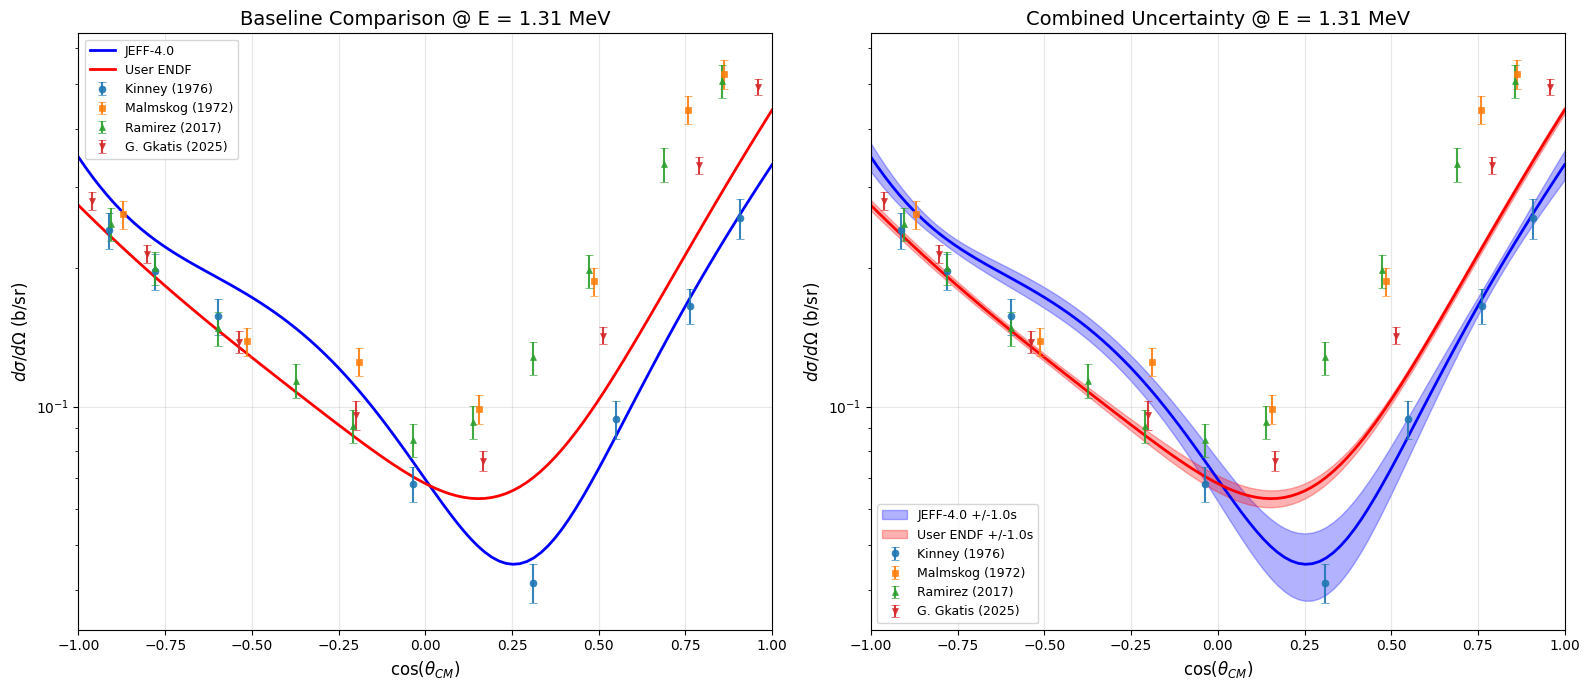

In [36]:
fig_comparison = plot_comparison(
    results_jeff, results_user, exfor_df, experiments_info,
    ANALYSIS_ENERGY_MEV, N_SIGMA, yscale=PLOT_YSCALE
)
plt.show()

## 11. Detailed Uncertainty Breakdown

JEFF-4.0: Individual Legendre Contributions


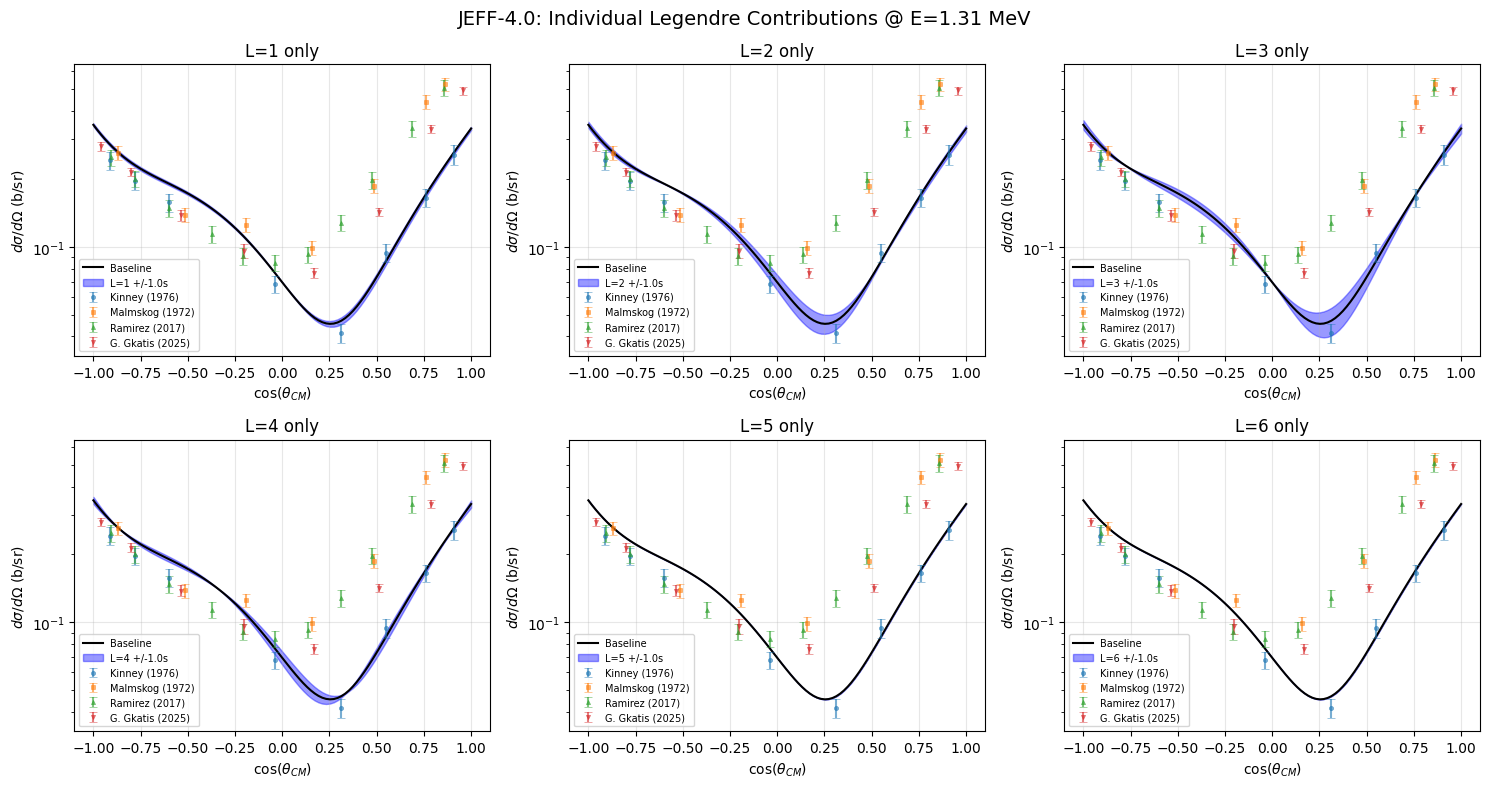

In [37]:
# =============================================================================
# JEFF-4.0: Individual Legendre Contributions (one plot per order)
# =============================================================================
print("JEFF-4.0: Individual Legendre Contributions")
print("=" * 60)
fig_jeff_individual = plot_individual_legendre_grid(
    results_jeff, 'JEFF-4.0', ANALYSIS_ENERGY_MEV, N_SIGMA, MAX_LEGENDRE_ORDER,
    exfor_df=exfor_df, experiments_info=experiments_info, yscale=PLOT_YSCALE
)
plt.show()

JEFF-4.0: Cumulative Legendre Contributions


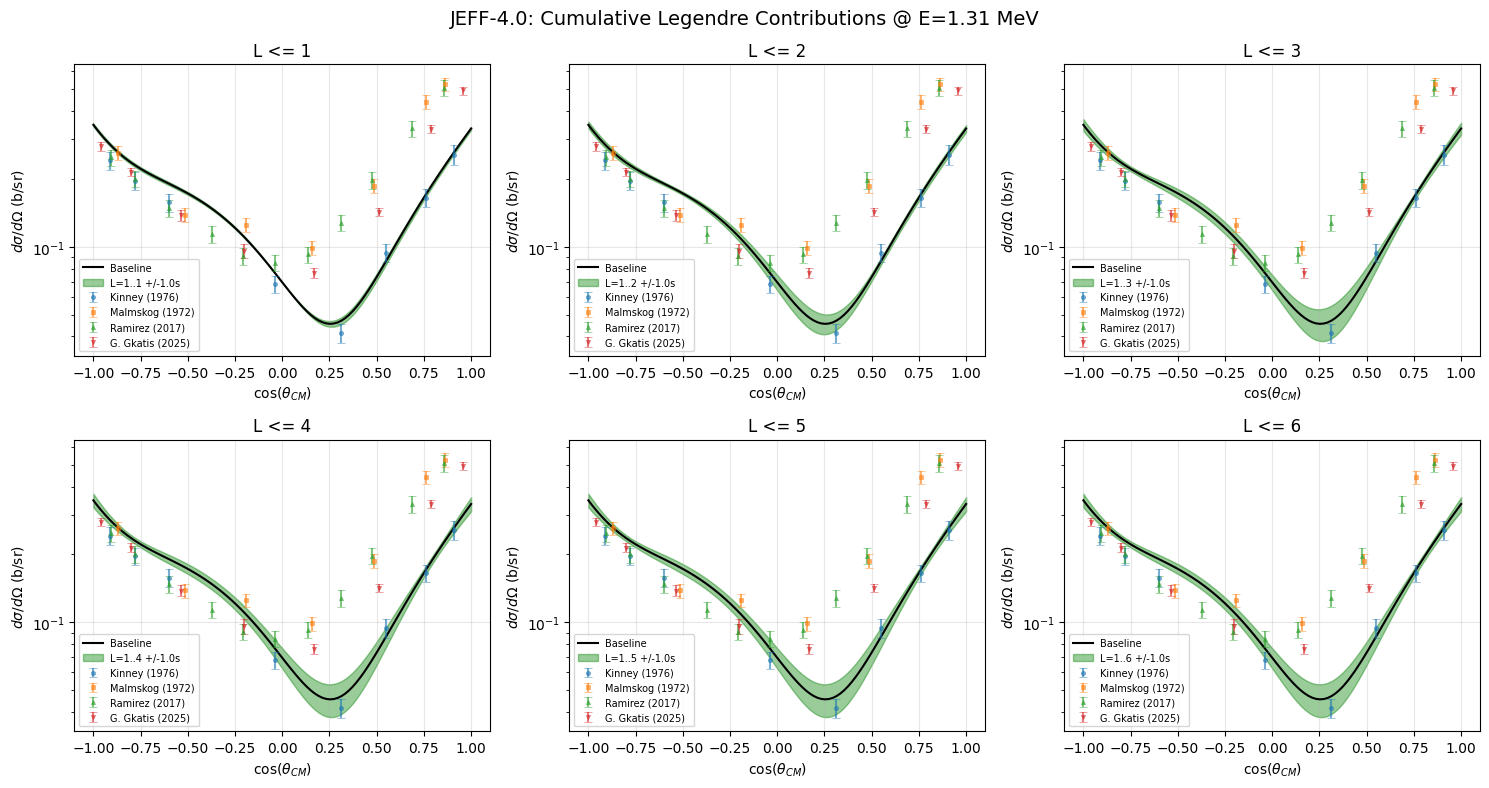

In [38]:
# =============================================================================
# JEFF-4.0: Cumulative Legendre Contributions (one plot per order)
# =============================================================================
print("JEFF-4.0: Cumulative Legendre Contributions")
print("=" * 60)
fig_jeff_cumulative = plot_cumulative_legendre_grid(
    results_jeff, 'JEFF-4.0', ANALYSIS_ENERGY_MEV, N_SIGMA, MAX_LEGENDRE_ORDER,
    exfor_df=exfor_df, experiments_info=experiments_info, yscale=PLOT_YSCALE
)
plt.show()

JEFF-4.0: Summary Breakdown


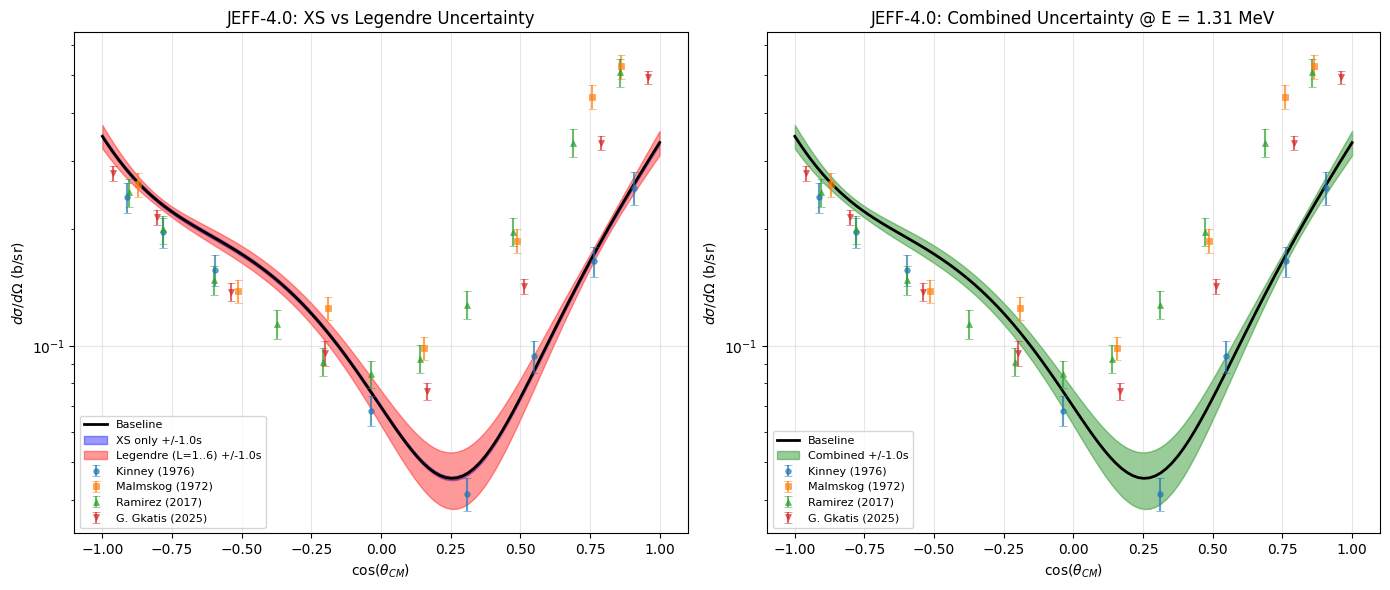

In [39]:
# =============================================================================
# JEFF-4.0: Summary (XS vs Legendre and Combined)
# =============================================================================
print("JEFF-4.0: Summary Breakdown")
print("=" * 60)
fig_jeff_summary = plot_summary_breakdown(
    results_jeff, 'JEFF-4.0', ANALYSIS_ENERGY_MEV, N_SIGMA, MAX_LEGENDRE_ORDER,
    exfor_df=exfor_df, experiments_info=experiments_info, yscale=PLOT_YSCALE
)
plt.show()

User ENDF: Individual Legendre Contributions


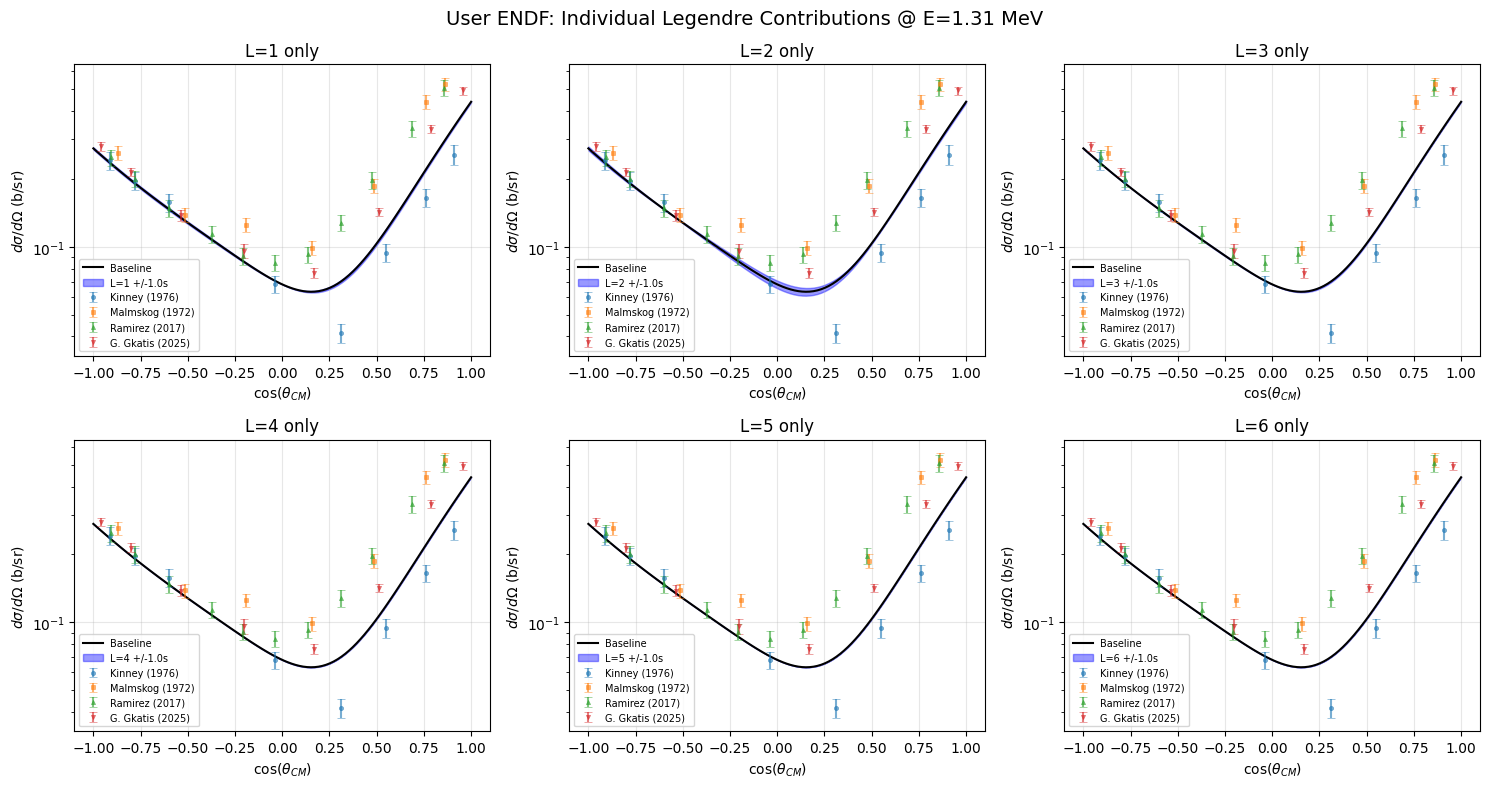


User ENDF: Cumulative Legendre Contributions


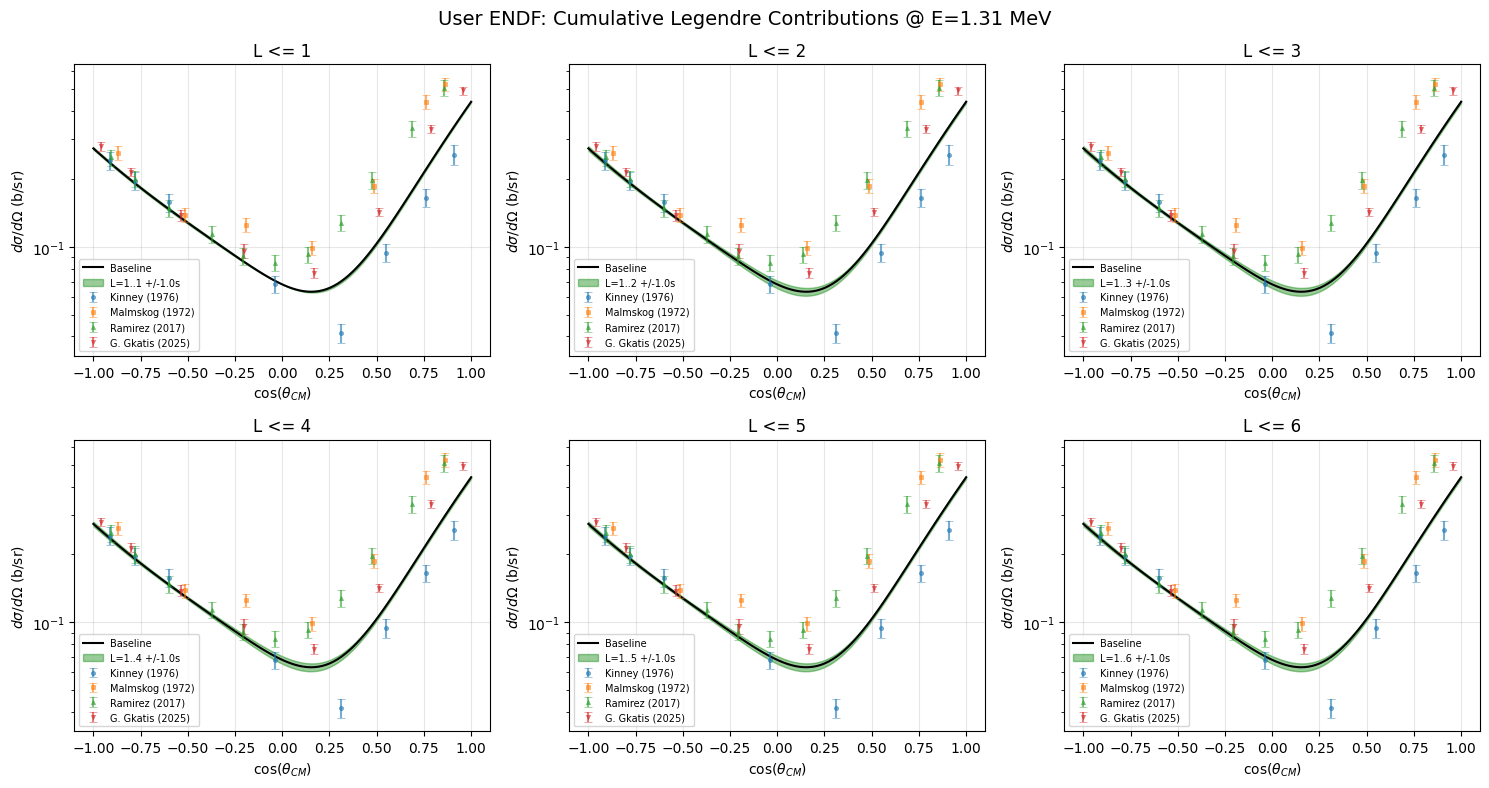


User ENDF: Summary Breakdown


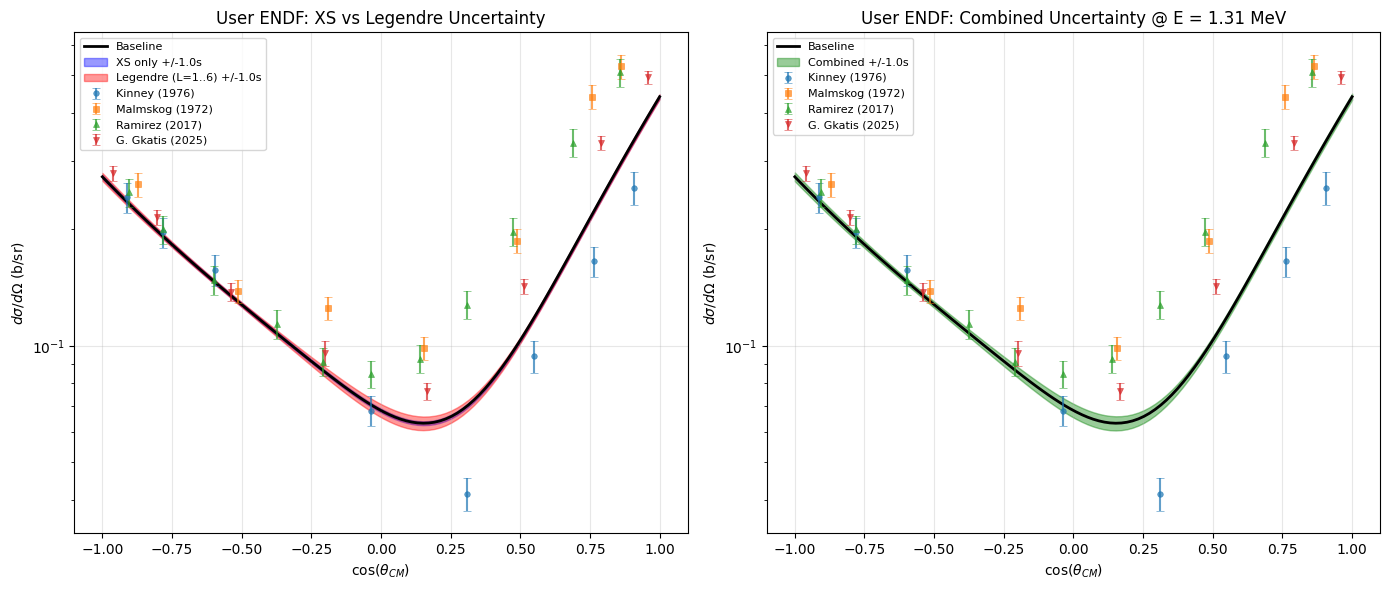

In [40]:
# =============================================================================
# User ENDF: Individual, Cumulative, and Summary Plots (if available)
# =============================================================================
if results_user is not None:
    user_max_order = min(MAX_LEGENDRE_ORDER, max(available_orders_user) if available_orders_user else MAX_LEGENDRE_ORDER)
    
    # Individual Legendre contributions
    print("User ENDF: Individual Legendre Contributions")
    print("=" * 60)
    fig_user_individual = plot_individual_legendre_grid(
        results_user, 'User ENDF', ANALYSIS_ENERGY_MEV, N_SIGMA, user_max_order,
        exfor_df=exfor_df, experiments_info=experiments_info, yscale=PLOT_YSCALE
    )
    plt.show()
    
    # Cumulative Legendre contributions
    print("\nUser ENDF: Cumulative Legendre Contributions")
    print("=" * 60)
    fig_user_cumulative = plot_cumulative_legendre_grid(
        results_user, 'User ENDF', ANALYSIS_ENERGY_MEV, N_SIGMA, user_max_order,
        exfor_df=exfor_df, experiments_info=experiments_info, yscale=PLOT_YSCALE
    )
    plt.show()
    
    # Summary (XS vs Legendre and Combined)
    print("\nUser ENDF: Summary Breakdown")
    print("=" * 60)
    fig_user_summary = plot_summary_breakdown(
        results_user, 'User ENDF', ANALYSIS_ENERGY_MEV, N_SIGMA, user_max_order,
        exfor_df=exfor_df, experiments_info=experiments_info, yscale=PLOT_YSCALE
    )
    plt.show()
else:
    print("User ENDF not available - skipping breakdown plots.")

## 12. Summary Statistics

In [41]:
print("=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)
print(f"\nEnergy: {ANALYSIS_ENERGY_MEV} MeV")
print(f"Confidence level: {N_SIGMA}σ")
print(f"Folding: {'Enabled' if APPLY_FOLDING else 'Disabled'}")
if APPLY_FOLDING:
    sigma_E = compute_energy_resolution_tof(ANALYSIS_ENERGY_MEV, config)
    print(f"  σE = {sigma_E * 1000:.2f} keV")

print(f"\n--- JEFF-4.0 ---")
print(f"Cross section: {results_jeff['baseline']['sigma_total']:.4f} b")
xs_rel_unc = get_cross_section_uncertainty(cov_matrix, ZAID, MT_ELASTIC, ANALYSIS_ENERGY_MEV)
print(f"XS rel. uncertainty: {xs_rel_unc * 100:.2f}%")

if results_user is not None:
    print(f"\n--- User ENDF ---")
    print(f"Cross section: {results_user['baseline']['sigma_total']:.4f} b")
else:
    print(f"\n--- User ENDF ---")
    print("Not available")

if exfor_df is not None and not exfor_df.empty:
    print(f"\n--- EXFOR Data ---")
    print(f"Data points: {len(exfor_df)}")
    print(f"Experiments: {len(experiments_info)}")
    print(f"Energy tolerance: ±{ENERGY_TOLERANCE*1000:.1f} keV")
    
    # List experiments
    print(f"\nExperiments used:")
    for exp in experiments_info:
        author = exp.get('author', 'Unknown')
        year = exp.get('year', '????')
        n_pts = exp.get('n_points', 0)
        e_exfor = exp.get('exfor_energy_mev', 0)
        print(f"  - {author} ({year}): {n_pts} points @ {e_exfor:.4f} MeV")
else:
    print(f"\n--- EXFOR Data ---")
    print("Not available")

print("\n" + "=" * 80)

ANALYSIS SUMMARY

Energy: 1.31 MeV
Confidence level: 1.0σ
Folding: Enabled
  σE = 6.51 keV

--- JEFF-4.0 ---
Cross section: 1.8451 b
XS rel. uncertainty: 1.16%

--- User ENDF ---
Cross section: 1.8451 b

--- EXFOR Data ---
Data points: 34
Experiments: 4
Energy tolerance: ±15.0 keV

Experiments used:
  - Kinney (1976): 8 points @ 1.3100 MeV
  - Malmskog (1972): 7 points @ 1.3000 MeV
  - Ramirez (2017): 11 points @ 1.3000 MeV
  - G. Gkatis (2025): 8 points @ 1.3099 MeV

